## Exercise 3




### First task: Read an image and convert it to a gray scale image

1. You should use all of the following -
    * matplotlib: imgGray = 0.2989 * R + 0.5870 * G + 0.1140 * B
    * skimage: skimage.io.imread(fname="test.png", as_gray=True)
    * opencv: cv.cvtColor(Farbbild, cv.COLOR_BGR2GRAY)

2. Compare in subplots the result of each method

##### RQ1 - Discuss the differences between the RGB image you used and the converted gray scale image from the perspective of arrays

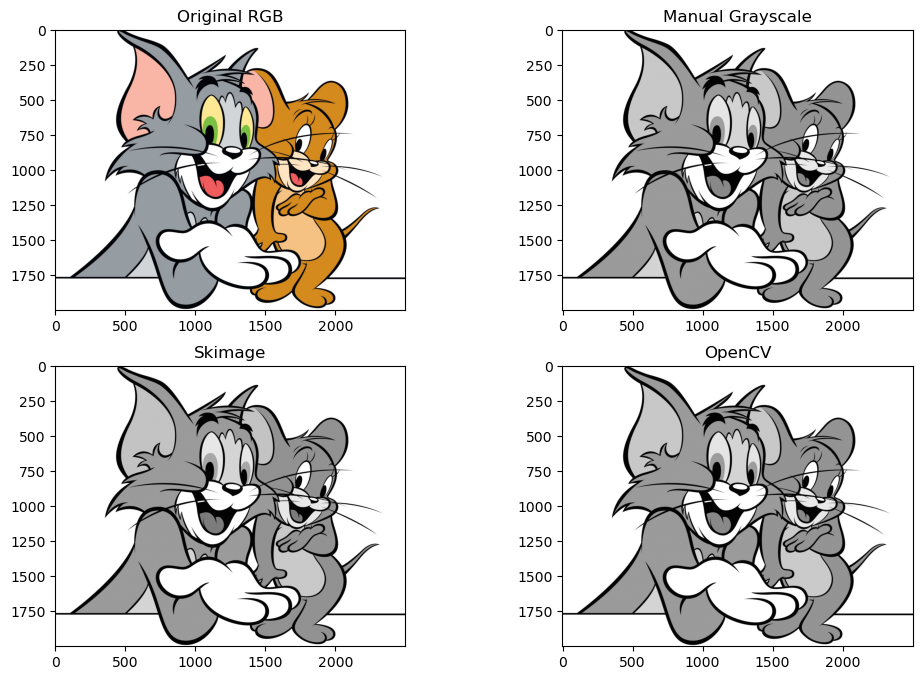

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import io
import cv2
# Read image
img = mpimg.imread("me.jpeg")

# Method 1: Manual grayscale
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

gray_manual = 0.2989 * R + 0.5870 * G + 0.1140 * B

# Method 2: skimage
gray_skimage = io.imread("me.jpeg", as_gray=True)

# Method 3: OpenCV
img_cv = cv2.imread("me.jpeg")
gray_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

# Plotting
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img)
plt.title("Original RGB")

plt.subplot(2,2,2)
plt.imshow(gray_manual, cmap='gray')
plt.title("Manual Grayscale")

plt.subplot(2,2,3)
plt.imshow(gray_skimage, cmap='gray')
plt.title("Skimage")

plt.subplot(2,2,4)
plt.imshow(gray_cv, cmap='gray')
plt.title("OpenCV")

plt.show()

####
    0.0S0.econd task: Create histograms of grayscale images
1. You should use all of the following -
    * numpy: np.histogram(image, bins=256, range=(0, 1))
    * opencv: cv.calcHist([I], [0], None, [256],[0,256])
    * matplolib: plt.hist(image.flatten(), bins=256, range=(0, 1)) 

2. Compare in subplots the result of each method

#### RQ2 - Discuss the modifiable parameters and their impact on the output results 

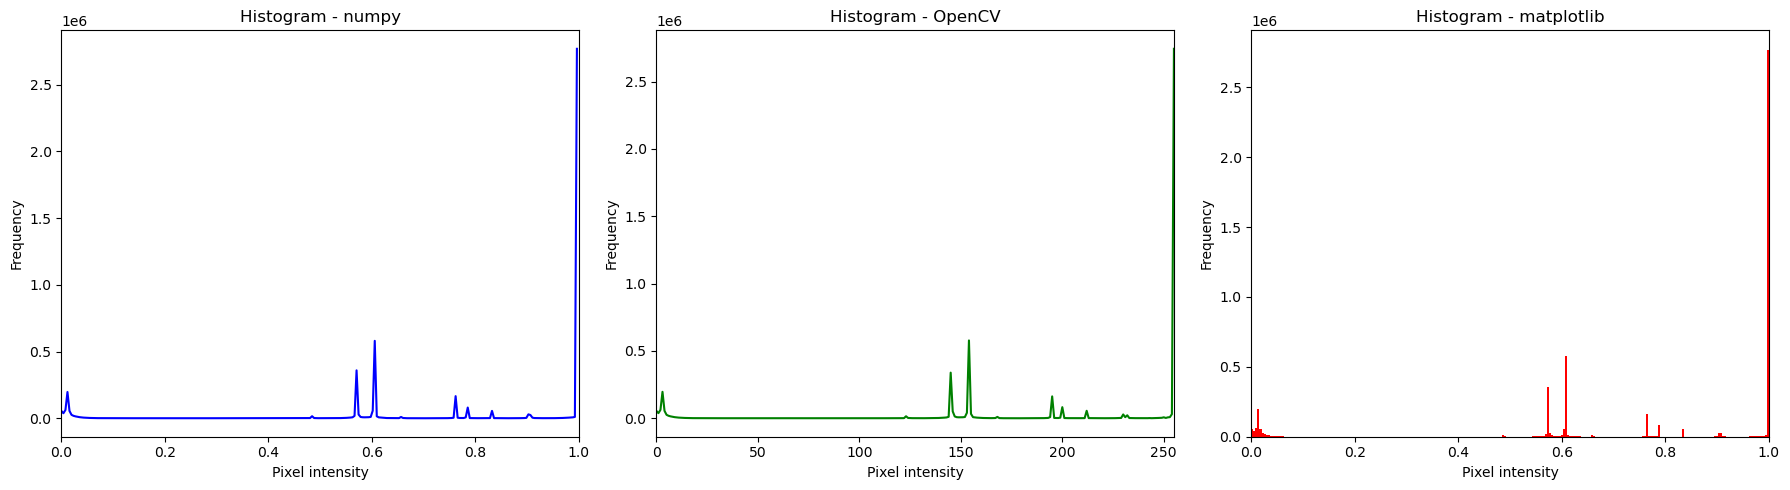

In [8]:

import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import io

# Load grayscale image using skimage (range [0,1])
img_skimage_gray = io.imread("me.jpeg", as_gray=True)

# For OpenCV histogram, we need the image in uint8 [0-255]
img_uint8 = (img_skimage_gray * 255).astype(np.uint8)

# 1) numpy histogram
hist_np, bins_np = np.histogram(img_skimage_gray, bins=256, range=(0, 1))

# 2) OpenCV histogram
hist_cv = cv2.calcHist([img_uint8], [0], None, [256], [0, 256])
hist_cv = hist_cv.flatten()  # flatten to 1D for plotting

# 3) matplotlib histogram
# (This one plots directly; we'll use plt.hist in the subplot below)

# Plot histograms side by side
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# numpy histogram plot
axs[0].plot(bins_np[:-1], hist_np, color='blue')
axs[0].set_title("Histogram - numpy")
axs[0].set_xlim(0, 1)
axs[0].set_xlabel("Pixel intensity")
axs[0].set_ylabel("Frequency")

# OpenCV histogram plot
axs[1].plot(np.arange(256), hist_cv, color='green')
axs[1].set_title("Histogram - OpenCV")
axs[1].set_xlim(0, 255)
axs[1].set_xlabel("Pixel intensity")
axs[1].set_ylabel("Frequency")

# matplotlib histogram plot
axs[2].hist(img_skimage_gray.flatten(), bins=256, range=(0, 1), color='red')
axs[2].set_title("Histogram - matplotlib")
axs[2].set_xlim(0, 1)
axs[2].set_xlabel("Pixel intensity")
axs[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()



### Third task: create histograms of color images
1. You should use all of the following -
    * numpy: np.histogram(image, bins=256, range=(0, 1))
    * opencv: cv.calcHist([I], [0], None, [256],[0,256])
    * matplolib: plt.hist(image.flatten(), bins=256, range=(0, 1)) 

2. Compare in subplots the result of each method

##### RQ3 - What is the difference between the histogram of a color image and a gray scale image? Discuss with your outputs.

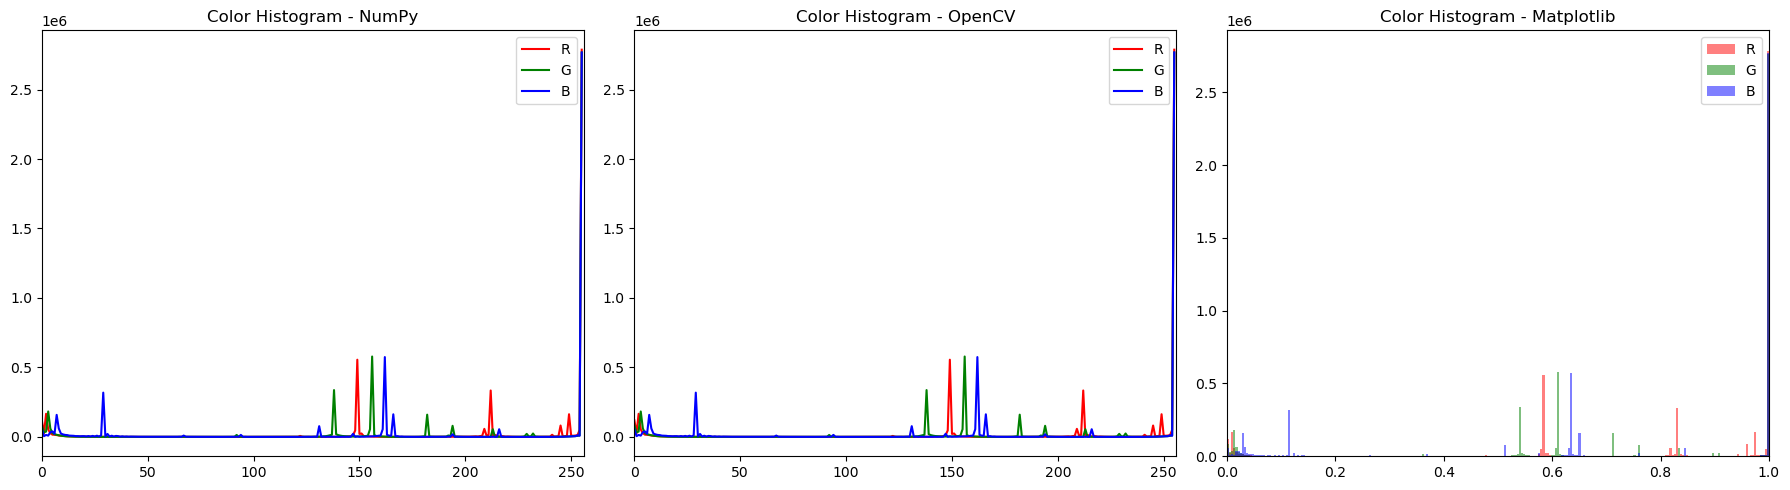

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load color image using OpenCV (BGR)
img_bgr = cv2.imread("me.jpeg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_float = img_rgb / 255.0  # Normalize for NumPy/Matplotlib histograms

# Separate channels
r, g, b = img_float[:, :, 0], img_float[:, :, 1], img_float[:, :, 2]

# === NumPy histograms (normalized image, float [0,1]) ===
hist_r_np, _ = np.histogram(r, bins=256, range=(0, 1))
hist_g_np, _ = np.histogram(g, bins=256, range=(0, 1))
hist_b_np, _ = np.histogram(b, bins=256, range=(0, 1))

# === OpenCV histograms (original BGR image, uint8 [0,255]) ===
hist_b_cv = cv2.calcHist([img_bgr], [0], None, [256], [0, 256]).flatten()
hist_g_cv = cv2.calcHist([img_bgr], [1], None, [256], [0, 256]).flatten()
hist_r_cv = cv2.calcHist([img_bgr], [2], None, [256], [0, 256]).flatten()

# === Matplotlib histograms ===
r_flat = r.flatten()
g_flat = g.flatten()
b_flat = b.flatten()

# === Plotting histograms ===
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# NumPy
axs[0].plot(hist_r_np, color='red', label='R')
axs[0].plot(hist_g_np, color='green', label='G')
axs[0].plot(hist_b_np, color='blue', label='B')
axs[0].set_title("Color Histogram - NumPy")
axs[0].set_xlim(0, 256)
axs[0].legend()

# OpenCV
axs[1].plot(hist_r_cv, color='red', label='R')
axs[1].plot(hist_g_cv, color='green', label='G')
axs[1].plot(hist_b_cv, color='blue', label='B')
axs[1].set_title("Color Histogram - OpenCV")
axs[1].set_xlim(0, 256)
axs[1].legend()

# Matplotlib
axs[2].hist(r_flat, bins=256, range=(0, 1), color='red', alpha=0.5, label='R')
axs[2].hist(g_flat, bins=256, range=(0, 1), color='green', alpha=0.5, label='G')
axs[2].hist(b_flat, bins=256, range=(0, 1), color='blue', alpha=0.5, label='B')
axs[2].set_title("Color Histogram - Matplotlib")
axs[2].set_xlim(0, 1)
axs[2].legend()

plt.tight_layout()
plt.show()


### Fourth task: Change the bin size of the histograms
1. You should use all of the following methods -    
    * numpy: np.histogram(image, bins=256, range=(0, 1))
    * opencv: cv.calcHist([I], [0], None, [256],[0,256])
    * matplolib: plt.hist(image.flatten(), bins=256, range=(0, 1))
2. Compare different bin sizes in subplots

##### RQ4 - What bin size should be selected? What information do you get from histograms? What applications do they have? Use your outputs to explain.

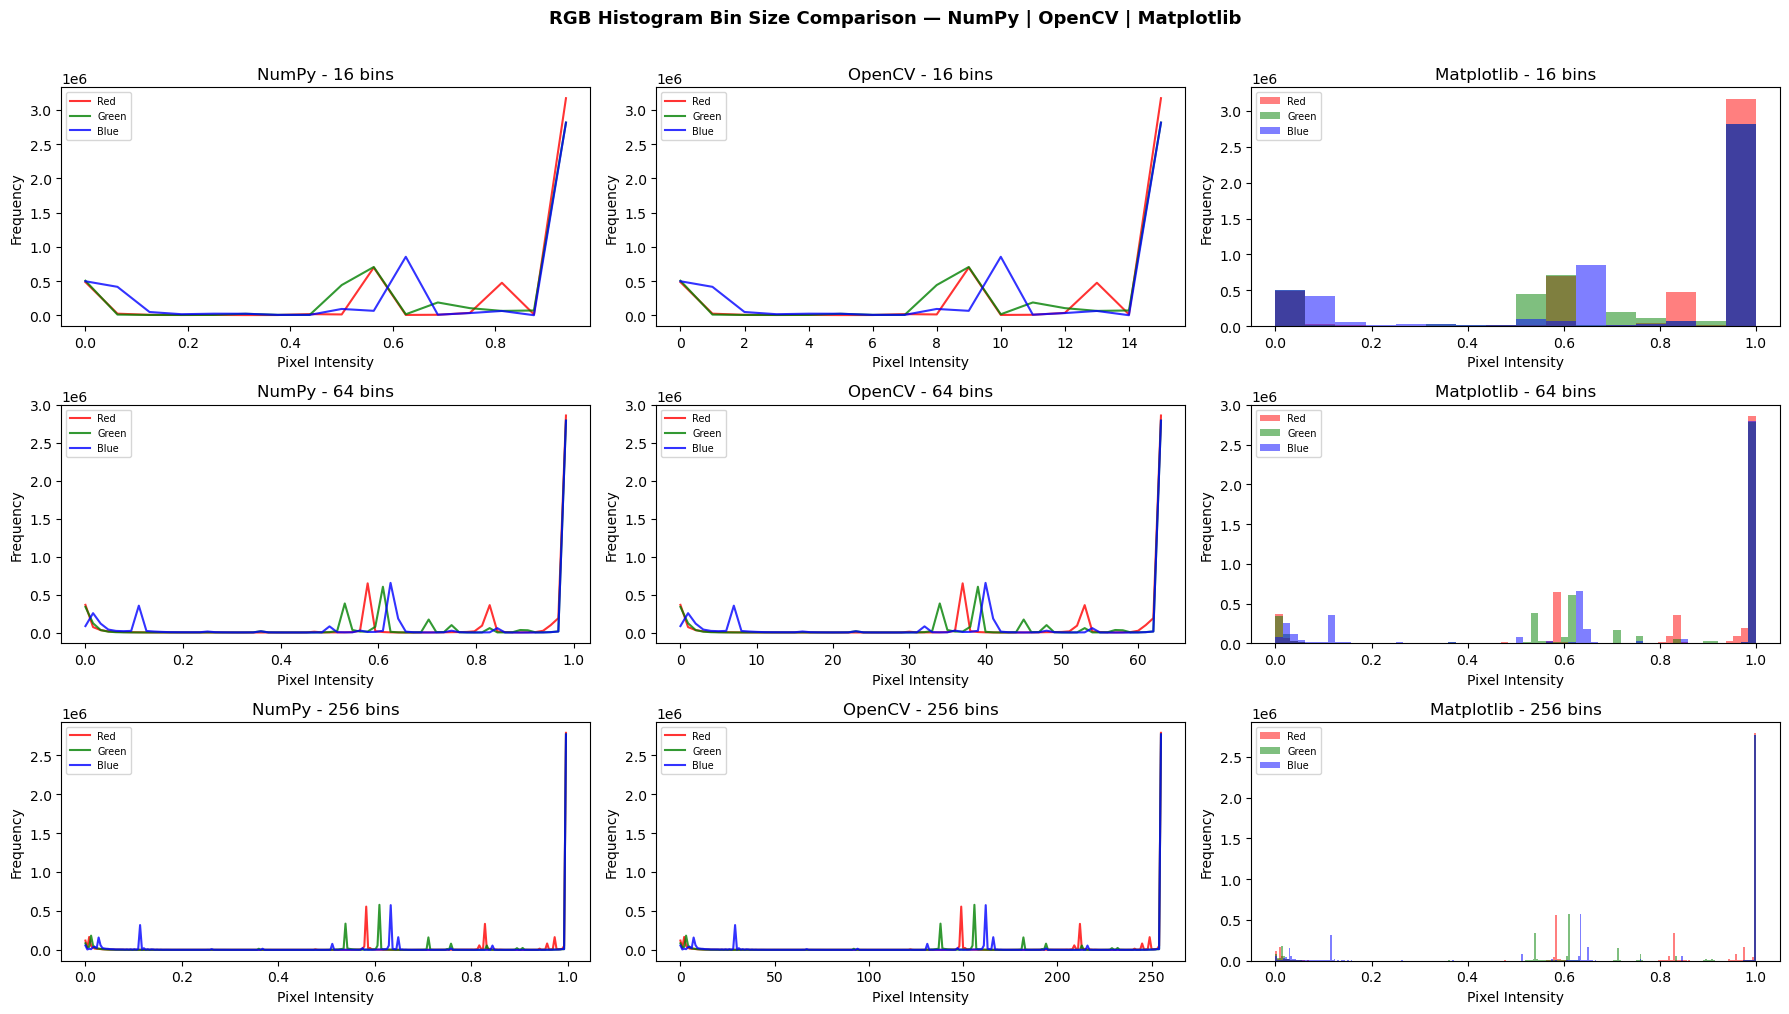

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load image
img_bgr   = cv2.imread("me.jpeg")                  # cv2 loads as BGR directly
img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # convert to RGB for numpy/mpl
img_float = img_rgb / 255.0

channels = [('Red', 'red', 0), ('Green', 'green', 1), ('Blue', 'blue', 2)]
bin_sizes = [16, 64, 256]

fig, axs = plt.subplots(len(bin_sizes), 3, figsize=(18, 10))
fig.suptitle("RGB Histogram Bin Size Comparison — NumPy | OpenCV | Matplotlib",
             fontsize=13, fontweight="bold", y=1.01)

for i, bins in enumerate(bin_sizes):
    for name, color, ch in channels:

        # NumPy
        hist, edges = np.histogram(img_float[:, :, ch], bins=bins, range=(0, 1))
        axs[i, 0].plot(edges[:-1], hist, color=color, label=name, alpha=0.8)

        # OpenCV (BGR channel order: R=2, G=1, B=0)
        hist_cv = cv2.calcHist([img_bgr], [2 - ch], None, [bins], [0, 256]).flatten()
        axs[i, 1].plot(hist_cv, color=color, label=name, alpha=0.8)

        # Matplotlib
        axs[i, 2].hist(img_float[:, :, ch].flatten(), bins=bins, range=(0, 1),
                       color=color, label=name, alpha=0.5)

    titles = [f"NumPy - {bins} bins", f"OpenCV - {bins} bins", f"Matplotlib - {bins} bins"]
    for ax, title in zip(axs[i], titles):
        ax.set(title=title, xlabel="Pixel Intensity", ylabel="Frequency")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("histogram_task4.png", dpi=150, bbox_inches="tight")
plt.show()